2) Regression Lineaire (simple,multiple,polynomiale)
   FROM SCRATCH

RÉGRESSION LINÉAIRE SIMPLE(from scratch)
ŷ =  (-0.0048) × weight + 53.0288 
R2 = 0.6333
MSE = 8.8428
________________________________________________________________________________
RÉGRESSION LINÉAIRE MULTIPLE (from scratch)
β0  = 46.5417
R2  = 0.7466
MSE = 6.1112
________________________________________________________________________________
RÉGRESSION POLYNOMIALE (from scratch)
ŷ = 53.2178 + -0.004967·x + 0.00000002·x²
R2 = 0.6329
MSE = 8.8539


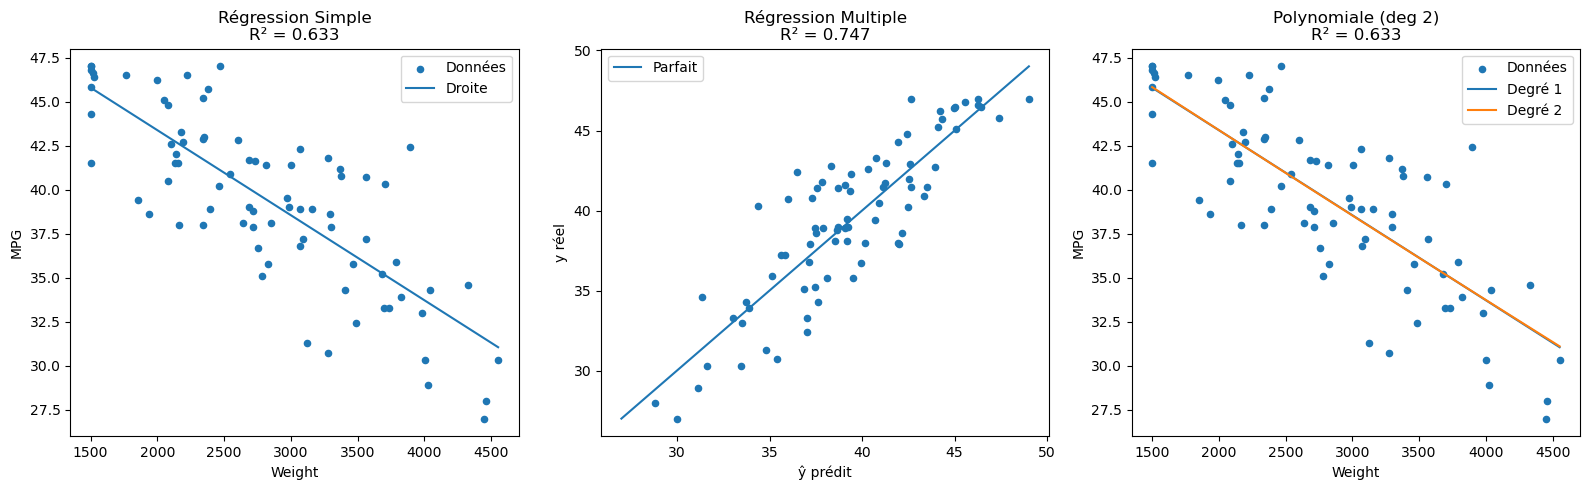

In [1]:
import numpy as np                           
import pandas as pd                          
import matplotlib.pyplot as plt              
from sklearn.model_selection import train_test_split  

df = pd.read_csv('auto_mpg.csv')           

print("RÉGRESSION LINÉAIRE SIMPLE(from scratch)")  #weight et mpg

X = df['weight'].values #variable explicative
y = df['mpg'].values    #variable a predire




X_train, X_test, y_train, y_test = train_test_split(      #separer les donnees en 2 set (training set test set) 
    X, y, test_size=0.2, random_state=42#                  20% des donnees pour test le reste pour entrainement
    )                   #NB: (random_state=42)pour obtenir 
#                        les memes set train/test 





def regression_simple_scratch(X, y):          #calcule  droite de régression ŷ= b1*X + b0 (y = ax +b)
    x_mean = np.mean(X) #moyenne de X
    y_mean = np.mean(y) #moyenne de y  
    b1 = np.sum((X - x_mean) * (y - y_mean)) / np.sum((X - x_mean) ** 2)  #la pente
    b0 = y_mean - b1 * x_mean                                             #l'intercept     
    return b0, b1                              



b0, b1 = regression_simple_scratch(X_train, y_train)   #appeler la fonction avec les données d'entraînement
pred = b0 + b1 * X_test #prédire mpg 





#métriques d'évaluation                           calcule
res = np.sum((y_test - pred) ** 2)               #RESIDUS
var = np.sum((y_test - np.mean(y_test)) ** 2)    #VARIANCE TOTAL 
R2_simple  = 1 - res / var                        #R2
MSE_simple = np.mean((y_test - pred) ** 2)       #MSE




print(f"ŷ =  ({b1:.4f}) × weight + {b0:.4f} ")  # y = ax +b
print(f"R2 = {R2_simple:.4f}")                  
print(f"MSE = {MSE_simple:.4f}")                

print("_" * 80)   





print("RÉGRESSION LINÉAIRE MULTIPLE (from scratch)")  #weight,horsepower,cylinders,model_year et mpg      

features = ['weight', 'horsepower', 'cylinders', 'model_year']  # dans ce cas (RL MILTIPLE) la variable explicative                                                                
X2 = df[features].values                                        # est sous forme d'une liste de plusieurs colonnes
y2 = df['mpg'].values# variable a predire

X2_train, X2_test, y2_train, y2_test = train_test_split(  # TRAIN/TEST
    X2, y2, test_size=0.2, random_state=42)               # 80%  /20%



def regression_multiple_scratch(X, y):                    
    n = X.shape[0]# récupérer nbr de voitures
    X_b = np.column_stack([np.ones(n), X])#ajouter une colonne des 1 pour calculer l'intercep
    betas = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y # equation normales ( β = (XᵀX)⁻¹ Xᵀy)
    return betas                                          







betas = regression_multiple_scratch(X2_train, y2_train)   
X2_test_b = np.column_stack([np.ones(len(y2_test)), X2_test]) #ajouter la colonne de 1 aux données de test
pred_multiple = X2_test_b @ betas # prédire mpg (NB : c'est β0+β1*X1+β2*X2+β3*X3+β4*X4 
#                                   mais par Multiplication matricielle (@) )   





R2_multiple  = 1 - np.sum((y2_test - pred_multiple) ** 2) / np.sum((y2_test - np.mean(y2_test)) ** 2)  #R2
MSE_multiple = np.mean((y2_test - pred_multiple) ** 2)   #MSE

print(f"β0  = {betas[0]:.4f}")  # afficher l'intercept (betas[0] --> β0 )


print(f"R2  = {R2_multiple:.4f}")                             
print(f"MSE = {MSE_multiple:.4f}")                            


print("_" * 80)   


print("RÉGRESSION POLYNOMIALE (from scratch)")   #weight,weight² et mpg     


X3 = df['weight'].values# variable explicative 
y3 = df['mpg'].values   # variable a predire


X3_train, X3_test, y3_train, y3_test = train_test_split( # TRAIN/TEST
    X3, y3, test_size=0.2, random_state=42)              # 80%  /20%   




def regression_poly_scratch(x, y, degree=2):                     
    X = np.column_stack([x ** d for d in range(degree + 1)]) #matrice vandermonde [1, x, x², ...] 
    betas = np.linalg.inv(X.T @ X) @ X.T @ y# équations normales(même formule que régression multiple ( β = (XᵀX)⁻¹ Xᵀy))
    return betas                                                   



b = regression_poly_scratch(X3_train, y3_train, degree=2) 
pred_poly = b[0] + b[1] * X3_test + b[2] * X3_test ** 2  # prédire mpg




R2_poly  = 1 - np.sum((y3_test - pred_poly) ** 2) / np.sum((y3_test - np.mean(y3_test)) ** 2)  # R2
MSE_poly = np.mean((y3_test - pred_poly) ** 2)  # MSE

print(f"ŷ = {b[0]:.4f} + {b[1]:.6f}·x + {b[2]:.8f}·x²") # ŷ = b0 + b1·x + b2·x²
print(f"R2 = {R2_poly:.4f}")                                          
print(f"MSE = {MSE_poly:.4f}")                                         










fig, axes = plt.subplots(1, 3, figsize=(16, 5))      



#RL simple
w_sorted = np.sort(X_test)                            
axes[0].scatter(X_test, y_test, s=20, label='Données')                     
axes[0].plot(w_sorted, b0 + b1 * w_sorted, label='Droite')                  
axes[0].set_title(f'Régression Simple\nR² = {R2_simple:.3f}')               
axes[0].set_xlabel('Weight')                          
axes[0].set_ylabel('MPG')                             
axes[0].legend()                                      



# RL multiple
axes[1].scatter(pred_multiple, y2_test, s=20)                                
mn, mx = min(y2_test.min(), pred_multiple.min()), max(y2_test.max(), pred_multiple.max()) 
axes[1].plot([mn, mx], [mn, mx], label='Parfait')                            
axes[1].set_title(f'Régression Multiple\nR² = {R2_multiple:.3f}')          
axes[1].set_xlabel('ŷ prédit')                       
axes[1].set_ylabel('y réel')                        
axes[1].legend()                                      



# RL POLYNOMIAL(deg 1 et deg 2)
b1_deg1 = regression_poly_scratch(X3_train, y3_train, degree=1)            
w_s = np.sort(X3_test)                                                     
axes[2].scatter(X3_test, y3_test, s=20, label='Données')                   
axes[2].plot(w_s, b1_deg1[0] + b1_deg1[1] * w_s, label='Degré 1')          
axes[2].plot(w_s, b[0] + b[1] * w_s + b[2] * w_s**2, label='Degré 2')     
axes[2].set_title(f'Polynomiale (deg 2)\nR² = {R2_poly:.3f}')             
axes[2].set_xlabel('Weight')                       
axes[2].set_ylabel('MPG')                             
axes[2].legend()                                    





plt.tight_layout()                                    
plt.savefig('resultats_RegLin_scratch.png', dpi=150)        
plt.show()                                           


3) Regression Lineaire (simple,multiple,polynomiale)
   scikit-learn

RÉGRESSION LINÉAIRE SIMPLE(scikit-learn)
b0= 53.0288
b1 = -0.004828
R² = 0.6333
MSE = 8.8428
________________________________________________________________________________
RÉGRESSION LINÉAIRE MULTIPLE (scikit-learn)
β0 = 46.5417
R²  = 0.7466
MSE = 6.1112
________________________________________________________________________________
RÉGRESSION POLYNOMIALE(scikit-learn)
b0 = 53.2178
b1 = -0.004967
b2 = 0.00000002
R²  = 0.6329
MSE = 8.8539


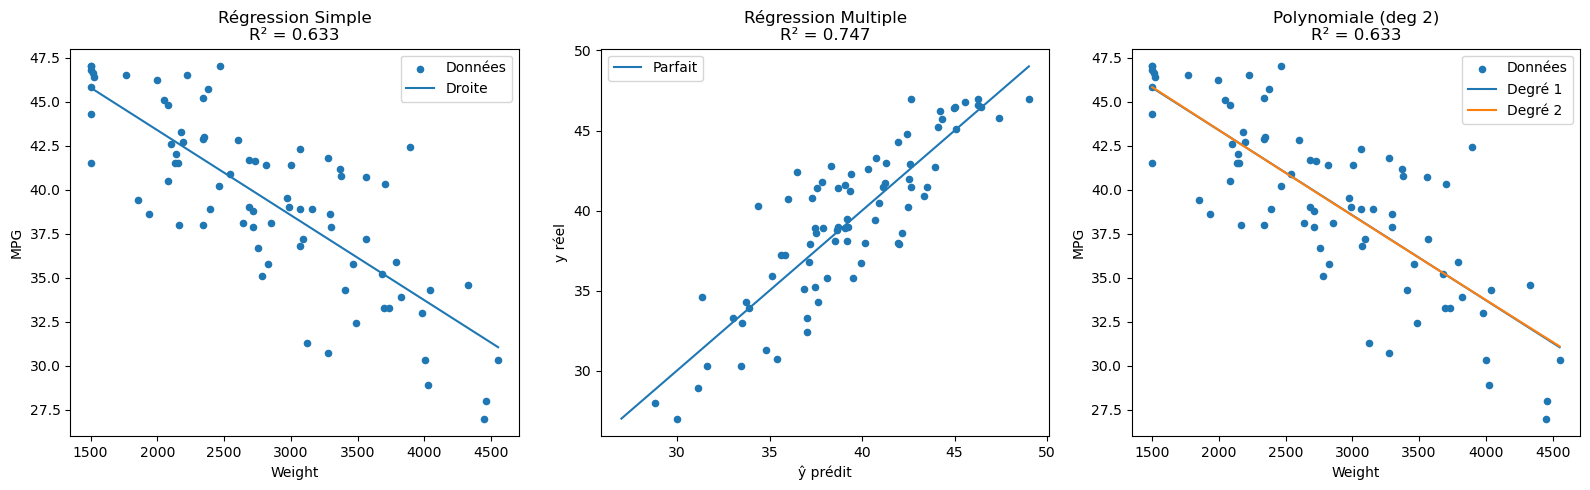

In [2]:
import numpy as np                          
import pandas as pd                         
import matplotlib.pyplot as plt             
from sklearn.linear_model import LinearRegression       
from sklearn.preprocessing import PolynomialFeatures     
from sklearn.pipeline import make_pipeline               
from sklearn.metrics import r2_score, mean_squared_error 
from sklearn.model_selection import train_test_split     

df = pd.read_csv('auto_mpg.csv')            



print("RÉGRESSION LINÉAIRE SIMPLE(scikit-learn)")  


X = df[['weight']].values  #variable explicative(format 2D requis par scikit-learn)
y = df['mpg'].values #variable a predire





X_train, X_test, y_train, y_test = train_test_split(     # TRAIN/TEST
    X, y, test_size=0.2, random_state=42)                # 80% /20%




                                                         
model_simple = LinearRegression() #creer modèle de RL simple
model_simple.fit(X_train, y_train)  #entrainer le modèle   (NB: b0 et b1 calcule automatiquement)
pred_simple = model_simple.predict(X_test)  #prédire mpg




print(f"b0= {model_simple.intercept_:.4f}")
print(f"b1 = {model_simple.coef_[0]:.6f}")    
print(f"R² = {r2_score(y_test, pred_simple):.4f}")          #R2
print(f"MSE = {mean_squared_error(y_test, pred_simple):.4f}")#MSE

# regression lineaire simple avec scikit-learn :
# LinearRegression() : cree le momodele de regression
# fit() : entraine le modele et calcule b0 et b1 auto
# predict() : prédire les valeurs de y
# r2_score() : calcule le coefficient de determination R2
# mean_squared_error() : calcule l’erreur quadratique moyenne (MSE)




print("_" * 80)





print("RÉGRESSION LINÉAIRE MULTIPLE (scikit-learn)")


features = ['weight', 'horsepower', 'cylinders', 'model_year']  # dans ce cas (RL MULTIPLE) la variable explicative
X2 = df[features].values                                         # est sous forme d'une liste de plusieurs colonnes
y2 = df['mpg'].values  # variable a predire



X2_train, X2_test, y2_train, y2_test = train_test_split(        # TRAIN/TEST
    X2, y2, test_size=0.2, random_state=42)                     # 80% /20%




model_multiple = LinearRegression()  
model_multiple.fit(X2_train, y2_train)           # entrainer le modèle : calcule β0 et βi automatiquement                                     
pred_multiple = model_multiple.predict(X2_test)    # prédire mpg 
                                             



print(f"β0 = {model_multiple.intercept_:.4f}")       # afficher l'intercept β0
print(f"R²  = {r2_score(y2_test, pred_multiple):.4f}")         #R2
print(f"MSE = {mean_squared_error(y2_test, pred_multiple):.4f}")#MSE

# scikit-learn calcule les coefficients β = (XᵀX)⁻¹ Xᵀy en interne 
# et la prédiction ŷ =β0+β1X1+β2X2+β3X3+β4X4 est faite automatiquement par predict()


print("_" * 80)                                                  
print("RÉGRESSION POLYNOMIALE(scikit-learn)")       



X3 = df[['weight']].values # variable explicative(2D)
y3 = df['mpg'].values  # variable a predire



X3_train, X3_test, y3_train, y3_test = train_test_split(  # TRAIN/TEST
    X3, y3, test_size=0.2, random_state=42)               # 80% /20%




model_poly = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=True),  # cree la matrice vandermonde 
    LinearRegression()    # applique la régression 
)




model_poly.fit(X3_train, y3_train)    # entrainer le modele : calcule b0,b1,b2 auto
y_pred_poly = model_poly.predict(X3_test)  # predire mpg
coefs = model_poly.named_steps['linearregression'].coef_    # recuperer b1 et b2
intercept = model_poly.named_steps['linearregression'].intercept_  # récupérer b0 (intercept)





print(f"b0 = {intercept:.4f}") # l'intercept 
print(f"b1 = {coefs[1]:.6f}")    # coef de x
print(f"b2 = {coefs[2]:.8f}")   # coef de x²
print(f"R²  = {r2_score(y3_test, y_pred_poly):.4f}")
print(f"MSE = {mean_squared_error(y3_test, y_pred_poly):.4f}")  












fig, axes = plt.subplots(1, 3, figsize=(16, 5))      

# rL simple
w_sorted = np.sort(X_test, axis=0)                 
axes[0].scatter(X_test, y_test, s=20, label='Données')                      
axes[0].plot(w_sorted, model_simple.predict(w_sorted), label='Droite')     
axes[0].set_title(f'Régression Simple\nR² = {r2_score(y_test, pred_simple):.3f}')  
axes[0].set_xlabel('Weight')                       
axes[0].set_ylabel('MPG')                            
axes[0].legend()                                    




# RL multiple
axes[1].scatter(pred_multiple, y2_test, s=20)                             
mn = min(y2_test.min(), pred_multiple.min())          
mx = max(y2_test.max(), pred_multiple.max())         
axes[1].plot([mn, mx], [mn, mx], label='Parfait')                          
axes[1].set_title(f'Régression Multiple\nR² = {r2_score(y2_test, pred_multiple):.3f}')  
axes[1].set_xlabel('ŷ prédit')                       
axes[1].set_ylabel('y réel')                         
axes[1].legend()                                     




# RL Polynomiale (deg 1 et deg 2)
model_deg1 = make_pipeline(PolynomialFeatures(degree=1), LinearRegression()) 
model_deg1.fit(X3_train, y3_train)                   
w_s = np.sort(X3_test, axis=0)                    
axes[2].scatter(X3_test, y3_test, s=20, label='Données')                    
axes[2].plot(w_s, model_deg1.predict(w_s), label='Degré 1')                 
axes[2].plot(w_s, model_poly.predict(w_s), label='Degré 2')                 
axes[2].set_title(f'Polynomiale (deg 2)\nR² = {r2_score(y3_test, y_pred_poly):.3f}')  
axes[2].set_xlabel('Weight')                          
axes[2].set_ylabel('MPG')                            
axes[2].legend()                                   





plt.tight_layout()                                    
plt.savefig('resultats_RegLin_library.png', dpi=150)         
plt.show()                                            
